[geometry OK] 42 regions tile exactly
              gaps: bottom 3.20 um / top 10.00 um | overhang 3.40 um | lower block 5.40 um wide | lift at x = 7.00 um
              SiO2 buffer 200 nm (h_buf = 50.0 nm) | electrodes 2.0 um | pad on 3.6 um lift | cap 2.0 x 1.4 um


Transforming over 1000 vertices to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


...

Transforming over 1000 elements to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


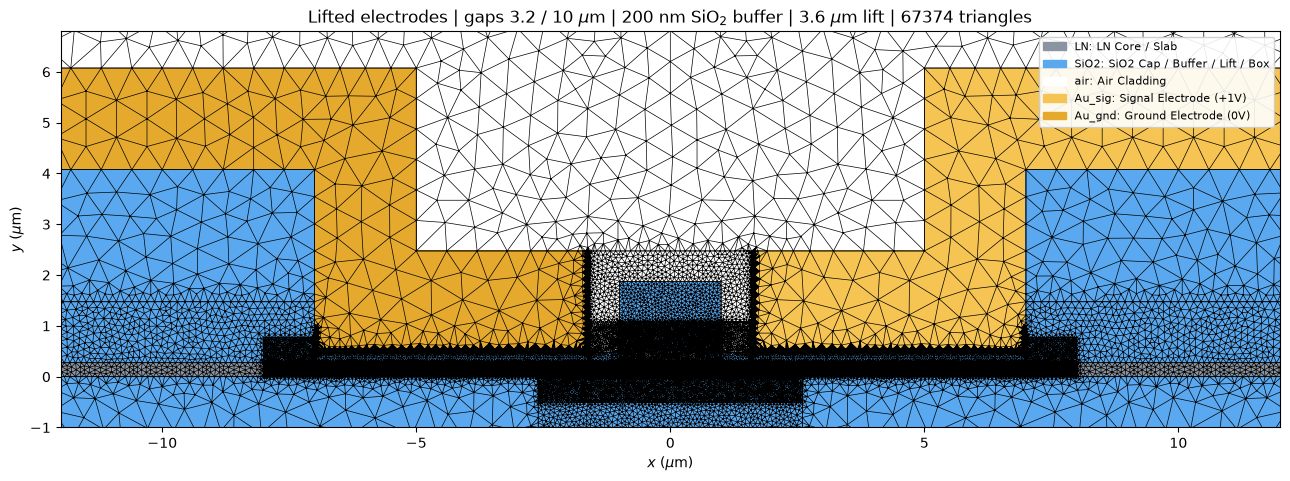

In [1]:
# %% [0] Geometry, Mesh & Material Configuration  --  LIFTED ELECTRODE ON A SiO2 BUFFER
#
#   Each electrode is ONE fused gold body made of three blocks:
#     lower block : sits on the SiO2 buffer, inner edge at the 3.2 um bottom gap
#     column      : 2.0 um wide riser on the outer end of the lower block
#     lifted pad  : runs outward on top of the 3.6 um SiO2 lift
#   The SiO2 buffer (BUFFER_H, 200 nm) covers the LN slab everywhere: under the
#   lower block, under the lift (where the two oxides form one layer) and across
#   the gap, where it fuses with the SiO2 cap.  BUFFER_H = 0 is supported and gives
#   back the plain lifted geometry (gold directly on the slab).
#
#   Vertical references (all measured from the buffer top = bottom of the gold):
#     lower block EL_H, SiO2 lift LIFT_H (pad bottom), pad EL_H, cap CAP_H.
import warnings
from collections import OrderedDict
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
from shapely.affinity import scale as _scale
from shapely.geometry import Polygon, box
from shapely.ops import unary_union
from shapely import set_precision
from skfem import MeshTri
from femwell.mesh import mesh_from_OrderedDict

warnings.filterwarnings("ignore")

# ------------------------------------------------------------------------------
# femwell bug fix.  mesh_from_OrderedDict() tries to switch off gmsh's
# "extend mesh size from boundary" with `gmsh.model.mesh.MeshSizeExtendFromBoundary = 0`,
# which only sets a Python attribute: the gmsh option is never changed.  As a
# result every fine region pushes its size deep into its neighbours, so the
# `resolutions` dict does not describe the real mesh.  This wrapper applies the
# options femwell intended, right when it installs its background field.
import gmsh
if not getattr(gmsh.model.mesh.field, "_size_fix", False):
    _orig_set_bg = gmsh.model.mesh.field.setAsBackgroundMesh

    def _set_bg_fixed(tag):
        _orig_set_bg(tag)
        gmsh.option.setNumber("Mesh.MeshSizeExtendFromBoundary", 0)
        gmsh.option.setNumber("Mesh.MeshSizeFromPoints", 0)
        gmsh.option.setNumber("Mesh.MeshSizeFromCurvature", 0)

    gmsh.model.mesh.field.setAsBackgroundMesh = _set_bg_fixed
    gmsh.model.mesh.field._size_fix = True

# ============================================================
# 1. FIXED PHYSICAL & GEOMETRIC PARAMETERS
# ============================================================
wl = 1.575          # um (base reference)
wl_m = wl * 1e-6
k0 = 2.0 * np.pi / wl               # 1/um
k0_m = k0 * 1e6                     # 1/m
L_cm = 1.0          # cm
V_bias = 1.0        # V
r33 = 30.8e-12      # m/V
n_guess = 1.8755
num_modes_search = 8

# ---- Vertical Dimensions (um) ------------------------------------------------
BOX_H = 4.7
TECN = 0.550
WG_H = 0.275
SLAB_H = TECN - WG_H                # 0.275 um (LN slab thickness)
BUFFER_H = 0.200                    # SiO2 buffer on the slab: under the electrodes, under the
                                    # lift and across the gap (0.0 = gold directly on the slab)
EL_H = 2.000                        # electrode thickness (lower block AND lifted pad)
LIFT_H = 3.600                      # SiO2 lift under the pad, from the buffer top to the pad bottom
CAP_H = 1.400                       # SiO2 cap on the rib, from the buffer top
CLAD_ABOVE = 2.000                  # air kept above the top of the electrodes

# ---- Horizontal Dimensions (um) ---------------------------------------------
WG_TOP = 1.0
ALPHA = 60.0
GAP_BOT = 3.2                       # gap between the lower blocks (on the buffer)
GAP_TOP = 10.0                      # gap between the columns (GAP_TOP = 2 * (x_lift - COL_W))
COL_W = 2.0                         # column (riser) width
CAP_W = 2.0                         # SiO2 cap width
EL_W = 30.0                         # total electrode width, from the gap edge outward
MARGIN = 5.0

basetta = WG_H / np.tan(np.deg2rad(ALPHA))
WG_BOTTOM = WG_TOP + 2.0 * basetta
OVERHANG = (GAP_TOP - GAP_BOT) / 2.0        # 3.4 um: lower block beyond the column
LOW_W = OVERHANG + COL_W                    # 5.4 um: lower-block width
X_LIFT = GAP_BOT / 2.0 + LOW_W              # 7.0 um: where the gold leaves the buffer
HAS_BUF = BUFFER_H > 1e-9
assert CAP_W > WG_BOTTOM, "cap must be wider than the rib base"
assert GAP_BOT > CAP_W, "cap must fit inside the bottom gap"
assert OVERHANG > 0 and EL_W > LOW_W, "inconsistent electrode dimensions"
assert LIFT_H > EL_H, "the pad must sit above the lower block"
assert BUFFER_H >= 0.0

# ---- Refractive Indices & Permittivities (at 1.575 um anchor) ----------------
ne, no = 2.136842, 2.210268
n_sio2 = 1.438749
eps_au = -120.7 - 11.9j             # Physical gold loss: Im(eps) < 0 in exp(+jwt)

# ---- Mesh scales -------------------------------------------------------------
# Convergence (BUFFER_H = 200 nm, gaps 3.2 / 10, x_lift = 7.0 um):
#   reference, everything near the mode refined 1.5-2x (220k triangles):
#       IL = 0.0473 dB/cm, Vpi*L = 2.1493 V*cm
#   these settings (67k triangles, ~75 s for 8 modes):
#       IL = 0.0481 dB/cm, Vpi*L = 2.1484 V*cm        (IL +1.7 %, Vpi*L -0.04 %)
#   one-at-a-time refinements (buffer 25/12.5 nm, skin 12/8 nm, slab 15 nm,
#   corners, lift step, far slab, gap/cap/core/BOX) all move IL by < 1 %.
# BUFFER_H = 0 falls back to the settings converged for the plain lifted model
# (12 nm skin: with gold directly on the slab the loss is 5x higher and the skin
# is the one parameter that matters).
h_core = 0.040
h_skin = 0.018 if HAS_BUF else 0.012        # the field decays into Au in ~22 nm

# Buffer: its size follows the layer THICKNESS (N_BUF_LAYERS elements across),
# capped at H_BUF_MAX.  A very thin buffer (< 50 nm) therefore gets a very fine,
# expensive mesh: cost ~ N_BUF_LAYERS^2 / BUFFER_H.
N_BUF_LAYERS = 4
H_BUF_MAX = 0.050
h_buf = min(BUFFER_H / N_BUF_LAYERS, H_BUF_MAX) if HAS_BUF else H_BUF_MAX

# Gold "skin": a 70 nm shell resolving the ~23 nm optical skin depth, only on the
# lower block (the column and the pad are >= 1.6 um from the mode):
#   * its whole bottom face (the loss channel), NOT graded;
#   * its inner wall (faces the rib across the gap), full height;
#   * the bottom of its outer wall, where the channel under the metal ends.
SKIN_T = 0.070
_SPLIT = min(2.5, 0.5 * LOW_W)
SKIN_SEGMENTS = [(0.0, _SPLIT, 1.0), (_SPLIT, LOW_W, 1.0)]  # offsets from the gap edge; kept
                                                            # as two regions for the loss map
OUTER_WALL_SKIN_H = 0.5
# Both bottom corners of each lower block carry a field singularity (metal wedge).
# A square patch of very fine mesh is carved around each of them, from every region
# it touches (metal / buffer or slab / air / lift SiO2), whatever BUFFER_H is.
CORNER_R = 0.050                    # corner patch half-size (um)
h_corner = 0.006                    # mesh size inside the corner patches (um)
# Where the gold leaves the buffer, the field guided in the buffer under the metal
# spills into the lift oxide: a short refined zone right outside the outer wall.
STEP_L = 1.0                        # length of that zone (um)
STEP_H = 0.300                      # its height above the buffer top (um)

MATERIALS = {
    "LN":     {"color": "#8b95a1", "eps_dc": (28.0, 44.0), "eps_opt": (ne**2, no**2, no**2), "desc": "LN Core / Slab"},
    "SiO2":   {"color": "#5aa9f0", "eps_dc": (3.75, 3.75), "eps_opt": (n_sio2**2, n_sio2**2, n_sio2**2), "desc": "SiO2 Cap / Buffer / Lift / Box"},
    "air":    {"color": "#ffffff", "eps_dc": (1.00, 1.00), "eps_opt": (1.00, 1.00, 1.00), "desc": "Air Cladding"},
    "Au_sig": {"color": "#f6c453", "eps_dc": (1.00, 1.00), "eps_opt": (eps_au, eps_au, eps_au), "desc": "Signal Electrode (+1V)"},
    "Au_gnd": {"color": "#e5a92e", "eps_dc": (1.00, 1.00), "eps_opt": (eps_au, eps_au, eps_au), "desc": "Ground Electrode (0V)"},
}

PREFIX_TO_MAT = [
    ("core", "LN"), ("cap", "SiO2"), ("buf", "SiO2"), ("lift", "SiO2"),
    ("slab", "LN"), ("box", "SiO2"), ("clad", "air"),
    ("elR", "Au_sig"), ("elL", "Au_gnd"),
]

def material_of(region_name):
    base = region_name.split("___")[0]
    for prefix, mat in PREFIX_TO_MAT:
        if base.startswith(prefix):
            return mat
    raise KeyError(f"Unknown material for region: {region_name}")

def mirror(p):
    return _scale(p, xfact=-1.0, yfact=1.0, origin=(0, 0))

def _mirror_name(name):
    """elR_* <-> elL_*, *_r <-> *_l (names of mirrored right-half regions)."""
    if name.startswith("elR"):
        return "elL" + name[3:]
    assert name.endswith("_r"), name
    return name[:-2] + "_l"

# ============================================================
# 2. GEOMETRY GENERATOR
# ============================================================
def build_polygons():
    xg = GAP_BOT / 2.0                              # 1.60 um  lower-block inner edge
    x_col_in = GAP_TOP / 2.0                        # 5.00 um  column inner edge
    x_col_out = x_col_in + COL_W                    # 7.00 um  column outer edge = lower-block outer edge
    x_el_outer = xg + EL_W                          # 31.60 um end of the lifted pad
    DEV_W = 2.0 * x_el_outer + 2.0 * MARGIN         # 73.20 um
    x_dev_max = DEV_W / 2.0                         # 36.60 um
    x_near = min(x_col_out + 15.0, x_dev_max - 2.0) # 22.00 um refined-slab boundary (capped
                                                    # so the lift can be pushed far out)

    y_slab_bot = 0.0
    y_slab_top = SLAB_H                             # 0.275
    y_el_bot = y_slab_top + BUFFER_H                # 0.475  buffer top = bottom of the gold
    y_low_top = y_el_bot + EL_H                     # 2.475  top of the lower block
    y_pad_bot = y_el_bot + LIFT_H                   # 4.075  pad bottom = lift top
    y_el_top = y_pad_bot + EL_H                     # 6.075  pad / column top
    y_cap_top = y_el_bot + CAP_H                    # 1.875
    y_clad_top = y_el_top + CLAD_ABOVE              # 8.075
    CLAD_H = y_clad_top - SLAB_H
    y_box_bot = -BOX_H
    y_fine_top = y_el_bot + 0.6                     # above this the mode is < -25 dB

    # ---- 1. LN Rib Core ------------------------------------------------------
    core_poly = Polygon([
        (-WG_BOTTOM / 2.0, y_slab_top),
        (-WG_TOP / 2.0, y_slab_top + WG_H),
        (WG_TOP / 2.0, y_slab_top + WG_H),
        (WG_BOTTOM / 2.0, y_slab_top),
    ])

    # ---- 2. SiO2 Cap (2.0 um wide, 1.4 um above the buffer; fused with the buffer)
    cap_poly = box(-CAP_W / 2.0, y_slab_top, CAP_W / 2.0, y_fine_top).difference(core_poly)
    cap_up = box(-CAP_W / 2.0, y_fine_top, CAP_W / 2.0, y_cap_top)

    # ---- 3. Electrode (right = signal), three blocks Boolean-fused ----------
    low_r = box(xg, y_el_bot, x_col_out, y_low_top)
    col_r = box(x_col_in, y_low_top, x_col_out, y_el_top)
    pad_r = box(x_col_out, y_pad_bot, x_el_outer, y_el_top)
    el_r = unary_union([low_r, col_r, pad_r])
    assert el_r.geom_type == "Polygon", "electrode blocks do not fuse into one body"

    # segment ends snapped to x_col_out: xg + LOW_W and GAP_TOP/2 + COL_W can differ by
    # ~1e-15 (float round-off), which leaves a zero-width sliver that gmsh rejects
    _xe = lambda b: x_col_out if b >= LOW_W - 1e-9 else xg + b
    skins_r = [box(xg + a, y_el_bot, _xe(b), y_el_bot + SKIN_T) for (a, b, _f) in SKIN_SEGMENTS]
    skins_r[0] = unary_union([skins_r[0],                                       # inner wall
                              box(xg, y_el_bot, xg + SKIN_T, y_low_top)])
    skins_r[-1] = unary_union([skins_r[-1],                                     # outer wall foot
                               box(x_col_out - SKIN_T, y_el_bot,
                                   x_col_out, y_el_bot + OUTER_WALL_SKIN_H)])
    bulk_r = el_r.difference(unary_union(skins_r))

    # ---- 4. SiO2 buffer (only if BUFFER_H > 0) ------------------------------
    #      in the gap (between the cap and the lower block) and under the lower block
    bufgap_r = box(CAP_W / 2.0, y_slab_top, xg, y_el_bot) if HAS_BUF else None
    bufel_r = box(xg, y_slab_top, x_col_out, y_el_bot) if HAS_BUF else None

    # ---- 5. SiO2 lift under the pad (+ the buffer under it: one oxide), to the edge
    #      step zone : right outside the outer wall, where the buffer field spills out
    #      near       : the bottom 1 um, where the slab field lives
    lift_step_full = box(x_col_out, y_slab_top, x_col_out + STEP_L, y_el_bot + STEP_H)
    lift_near_full = box(x_col_out, y_slab_top, x_near, y_el_bot + 1.0)
    lift_step_r = lift_step_full
    lift_near_r = lift_near_full.difference(lift_step_full)
    lift_far_r = box(x_col_out, y_slab_top, x_dev_max, y_pad_bot).difference(lift_near_full)

    # ---- 6. LN Slab ----------------------------------------------------------
    slab_fine_full = box(-(x_col_out + 1.0), y_slab_bot, x_col_out + 1.0, y_slab_top)
    slab_fine = slab_fine_full
    slab_mid = box(-x_near, y_slab_bot, x_near, y_slab_top).difference(slab_fine_full)
    slab_far = box(-x_dev_max, y_slab_bot, x_dev_max, y_slab_top).difference(
        box(-x_near, y_slab_bot, x_near, y_slab_top))

    # ---- 7. SiO2 Underclad (BOX) --------------------------------------------
    # Fine only in the top 0.5 um (the mode's BOX tail decays as exp(-4.85 y/um)).
    box_near = box(-(xg + 1.0), -0.5, xg + 1.0, y_slab_bot)
    box_mid = box(-(xg + 1.0), -1.5, xg + 1.0, -0.5)
    box_far = box(-x_dev_max, y_box_bot, x_dev_max, y_slab_bot).difference(
        box(-(xg + 1.0), -1.5, xg + 1.0, y_slab_bot))

    # ---- 8. Air Cladding -----------------------------------------------------
    right = [el_r, lift_step_r, lift_near_r, lift_far_r] + ([bufgap_r, bufel_r] if HAS_BUF else [])
    solids = [core_poly, cap_poly, cap_up] + right + [mirror(p) for p in right]
    clad_all = box(-x_dev_max, y_slab_top, x_dev_max, y_clad_top).difference(unary_union(solids))
    clad_gap = clad_all.intersection(box(-xg, y_slab_top, xg, y_fine_top))
    clad_gap_up = clad_all.intersection(box(-xg, y_fine_top, xg, y_cap_top + 0.6))
    clad_far = clad_all.difference(box(-xg, y_slab_top, xg, y_cap_top + 0.6))

    # ---- 9. Assemble: centre regions + right-half regions and their mirrors ---
    centre = OrderedDict([
        ("core", core_poly), ("cap", cap_poly), ("cap_up", cap_up),
        ("slab_fine", slab_fine), ("slab_mid", slab_mid), ("slab_far", slab_far),
        ("box_near", box_near), ("box_mid", box_mid), ("box_far", box_far),
        ("clad_gap", clad_gap), ("clad_gap_up", clad_gap_up), ("clad_far", clad_far),
    ])
    halves = OrderedDict()
    for i, sk in enumerate(skins_r):
        halves[f"elR_skin{i}"] = sk
    halves["elR_bulk"] = bulk_r
    if HAS_BUF:
        halves["bufgap_r"] = bufgap_r
        halves["bufel_r"] = bufel_r
    halves["lift_step_r"] = lift_step_r
    halves["lift_near_r"] = lift_near_r
    halves["lift_far_r"] = lift_far_r
    for _n in list(halves):
        halves[_mirror_name(_n)] = mirror(halves[_n])

    # ---- 10. Corner patches: carve a (2r x 2r) square around each bottom corner
    #      of each lower block out of EVERY region it touches; each piece keeps the
    #      material of its parent (name prefix) and gets the h_corner mesh.
    r = CORNER_R
    corner_pts = {"cRI": (xg, y_el_bot), "cRO": (x_col_out, y_el_bot),
                  "cLI": (-xg, y_el_bot), "cLO": (-x_col_out, y_el_bot)}
    polys = OrderedDict(list(centre.items()) + list(halves.items()))
    pieces = OrderedDict()
    for tag, (cx, cy) in corner_pts.items():
        patch = box(cx - r, cy - r, cx + r, cy + r)
        for name in list(polys):
            piece = polys[name].intersection(patch)
            if piece.area > 1e-12:
                pieces[f"{name}_{tag}"] = piece
                polys[name] = polys[name].difference(patch)
    polys.update(pieces)
    # Snap every region to a 1 pm grid: coordinates that should coincide but differ by
    # float round-off (e.g. BUFFER_H == CORNER_R) would otherwise leave zero-width slivers
    # that gmsh rejects.  Regions that collapse entirely are dropped.
    polys = OrderedDict((k, set_precision(v, 1e-6)) for k, v in polys.items())
    polys = OrderedDict((k, v) for k, v in polys.items() if v.area > 1e-12)
    return polys, DEV_W, CLAD_H

# ============================================================
# 3. MESH GENERATION & RESOLUTION SETUP
# ============================================================
polygons, DEV_W, CLAD_H = build_polygons()

_base_res = {
    "core":        {"resolution": h_core,       "distance": 0.30},
    "cap":         {"resolution": 0.035,        "distance": 0.30},
    "cap_up":      {"resolution": 0.080,        "distance": 0.30},
    "clad_gap":    {"resolution": 0.040,        "distance": 0.30},
    "clad_gap_up": {"resolution": 0.100,        "distance": 0.30},
    "slab_fine":   {"resolution": 0.025,        "distance": 0.30},
    "slab_mid":    {"resolution": 0.110,        "distance": 0.40},
    "slab_far":    {"resolution": 0.150,        "distance": 0.50},
    "box_near":    {"resolution": 0.040,        "distance": 0.30},
    "box_mid":     {"resolution": 0.100,        "distance": 0.30},
    "box_far":     {"resolution": 0.800,        "distance": 1.00},
    "bufgap":      {"resolution": h_buf,        "distance": 0.20},
    "bufel":       {"resolution": h_buf,        "distance": 0.20},
    "lift_step":   {"resolution": 0.040,        "distance": 0.30},
    "lift_near":   {"resolution": 0.150,        "distance": 0.40},
    "lift_far":    {"resolution": 0.800,        "distance": 1.00},
    "elR_bulk":    {"resolution": 0.800,        "distance": 0.50},
    "elL_bulk":    {"resolution": 0.800,        "distance": 0.50},
    "clad_far":    {"resolution": 0.800,        "distance": 1.00},
}
for _i, (_a, _b, _f) in enumerate(SKIN_SEGMENTS):
    for _s in ("R", "L"):
        _base_res[f"el{_s}_skin{_i}"] = {"resolution": _f * h_skin, "distance": 0.20}

def _res_key(name):
    for suffix in ("_r", "_l"):
        if name.endswith(suffix) and name[:-2] in _base_res:
            return name[:-2]
    return name

resolutions = {}
for _k in polygons:
    if _k[-4:] in ("_cRI", "_cRO", "_cLI", "_cLO"):
        resolutions[_k] = {"resolution": h_corner, "distance": 0.10}
    else:
        resolutions[_k] = _base_res[_res_key(_k)]

# ---- Validity / consistency assertions ---------------------------------------
assert set(resolutions) == set(polygons), (
    f"resolution/polygon mismatch: {set(resolutions) ^ set(polygons)}")
_names = list(polygons)
for _n, _p in polygons.items():
    assert _p.is_valid and not _p.is_empty and _p.area > 1e-12, f"degenerate region {_n}"
for _i in range(len(_names)):
    for _j in range(_i + 1, len(_names)):
        _ov = polygons[_names[_i]].intersection(polygons[_names[_j]]).area
        assert _ov < 1e-10, f"overlap {_names[_i]} & {_names[_j]}: {_ov:.2e}"
_tot = sum(p.area for p in polygons.values())
assert abs(_tot - DEV_W * (BOX_H + SLAB_H + CLAD_H)) < 1e-8, "tiling gap"

print(f"[geometry OK] {len(polygons)} regions tile exactly")
print(f"              gaps: bottom {GAP_BOT:.2f} um / top {GAP_TOP:.2f} um | "
      f"overhang {OVERHANG:.2f} um | lower block {LOW_W:.2f} um wide | lift at x = {X_LIFT:.2f} um")
if HAS_BUF:
    print(f"              SiO2 buffer {BUFFER_H*1e3:.0f} nm (h_buf = {h_buf*1e3:.1f} nm) | "
          f"electrodes {EL_H:.1f} um | pad on {LIFT_H:.1f} um lift | cap {CAP_W:.1f} x {CAP_H:.1f} um")
else:
    print(f"              NO buffer: gold on the LN slab | "
          f"electrodes {EL_H:.1f} um | pad on {LIFT_H:.1f} um lift | cap {CAP_W:.1f} x {CAP_H:.1f} um")

raw_mesh = mesh_from_OrderedDict(
    polygons,
    resolutions=resolutions,
    default_resolution_min=0.5 * min(h_skin, h_corner),
    default_resolution_max=0.6,
)
skfem_mesh = MeshTri(raw_mesh.points[:, :2].T, raw_mesh.cells_dict["triangle"].T)
tri_subdomains = raw_mesh.cell_data_dict["gmsh:physical"]["triangle"]
name_to_id = {
    name: data[0] if hasattr(data, "__getitem__") else data
    for name, data in raw_mesh.field_data.items()
}

mat_of_el = np.empty(skfem_mesh.nelements, dtype=object)
for raw_name, s_id in name_to_id.items():
    if raw_name.split("___")[0] in polygons:
        mat_of_el[tri_subdomains == s_id] = material_of(raw_name)

assert not np.any(mat_of_el == None), (  # noqa: E711
    f"{int(np.sum(mat_of_el == None))} unassigned elements")  # noqa: E711
print(f"[mesh OK] {skfem_mesh.nelements} triangles, {skfem_mesh.nvertices} vertices")

# ---- Cross-section visualization ---------------------------------------------
fig, ax = plt.subplots(figsize=(13, 4.8))
legend_patches = []
seen = set()

for raw_name, s_id in name_to_id.items():
    if raw_name.split("___")[0] not in polygons:
        continue
    mat_key = material_of(raw_name)
    col = MATERIALS[mat_key]["color"]
    elem_idx = np.where(tri_subdomains == s_id)[0]
    if elem_idx.size == 0:
        continue
    sub_mesh = MeshTri(skfem_mesh.p, skfem_mesh.t[:, elem_idx])
    sub_mesh.plot(np.zeros(sub_mesh.nelements), ax=ax, shading="flat",
                  cmap=plt.matplotlib.colors.ListedColormap([col]))
    sub_mesh.draw(ax=ax, color="black", lw=0.15)
    if mat_key not in seen:
        legend_patches.append(mpatches.Patch(color=col, label=f"{mat_key}: {MATERIALS[mat_key]['desc']}"))
        seen.add(mat_key)

ax.legend(handles=legend_patches, loc="upper right", framealpha=0.9, fontsize=8)
_buf_txt = rf"{BUFFER_H*1e3:.0f} nm $\mathrm{{SiO}}_2$ buffer" if HAS_BUF else "no buffer"
ax.set_title(rf"Lifted electrodes | gaps {GAP_BOT:.1f} / {GAP_TOP:.0f} $\mu$m | {_buf_txt} | "
             rf"{LIFT_H:.1f} $\mu$m lift | {skfem_mesh.nelements} triangles")
ax.set_xlim([-12.0, 12.0])
ax.set_ylim([-1.0, 6.8])
ax.set_xlabel(r"$x$ ($\mu$m)")
ax.set_ylabel(r"$y$ ($\mu$m)")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

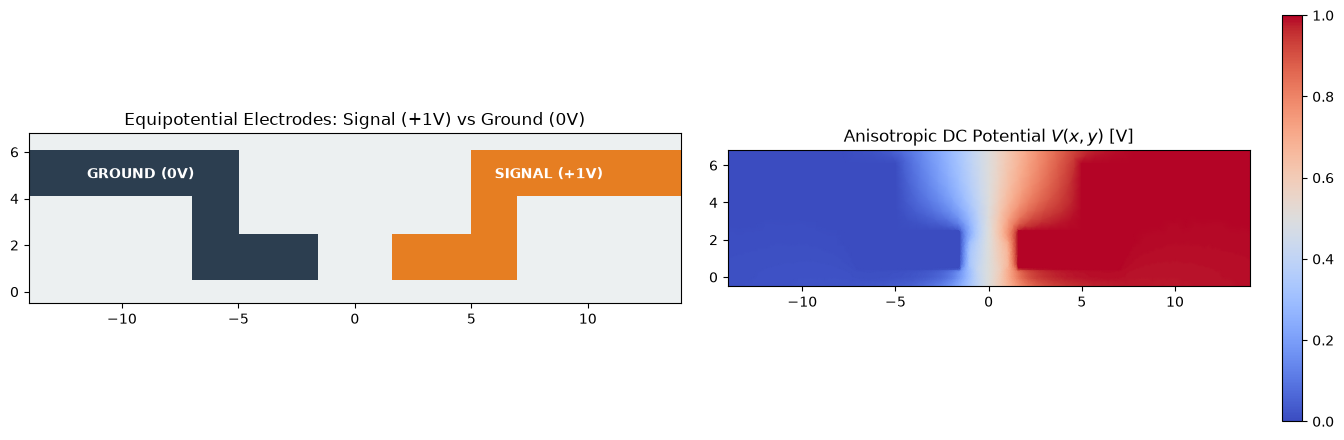

In [2]:
# %% [1] Anisotropic DC Electrostatics
from skfem import Basis, ElementTriP0, ElementTriP1, BilinearForm, asm, condense, solve
from skfem.helpers import grad

basis_dc = Basis(skfem_mesh, ElementTriP1(), intorder=4)
basis_p0 = Basis(skfem_mesh, ElementTriP0(), intorder=4)

eps_dc_x = np.array([MATERIALS[m]["eps_dc"][0] for m in mat_of_el], dtype=float)
eps_dc_y = np.array([MATERIALS[m]["eps_dc"][1] for m in mat_of_el], dtype=float)

@BilinearForm
def laplace_aniso(u, v, w):
    return w.eps_x * grad(u)[0] * grad(v)[0] + w.eps_y * grad(u)[1] * grad(v)[1]

K = asm(
    laplace_aniso,
    basis_dc,
    eps_x=basis_p0.interpolate(eps_dc_x),
    eps_y=basis_p0.interpolate(eps_dc_y),
)

sig_elements = np.where(mat_of_el == "Au_sig")[0]
gnd_elements = np.where(mat_of_el == "Au_gnd")[0]

dofs_signal = basis_dc.get_dofs(elements=sig_elements).all()
dofs_ground = basis_dc.get_dofs(elements=gnd_elements).all()
dofs_dirichlet = np.unique(np.concatenate([dofs_signal, dofs_ground]))

u_dirichlet = np.zeros(basis_dc.N)
u_dirichlet[dofs_signal] = V_bias
u_dirichlet[dofs_ground] = 0.0

K_c, f_c, u_c, I = condense(K, np.zeros(basis_dc.N), x=u_dirichlet, D=dofs_dirichlet)
potential_nodes = u_c.copy()
potential_nodes[I] = solve(K_c, f_c)

grad_V = basis_dc.interpolate(potential_nodes).grad
Ex_dc = -np.mean(grad_V[0], axis=-1) if grad_V.ndim == 3 else -grad_V[0]

# Diagnostic plots
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

ax0 = axes[0]
electrode_field = np.zeros(skfem_mesh.nelements)
electrode_field[mat_of_el == "Au_sig"] = 1.0
electrode_field[mat_of_el == "Au_gnd"] = -1.0

skfem_mesh.plot(electrode_field, ax=ax0, shading="flat", cmap=plt.matplotlib.colors.ListedColormap(["#2c3e50", "#ecf0f1", "#e67e22"]))
ax0.text(GAP_TOP / 2 + 1.0, SLAB_H + BUFFER_H + LIFT_H + 0.8, "SIGNAL (+1V)", color="white", fontweight="bold")
ax0.text(-GAP_TOP / 2 - 6.5, SLAB_H + BUFFER_H + LIFT_H + 0.8, "GROUND (0V)", color="white", fontweight="bold")
ax0.set_title("Equipotential Electrodes: Signal (+1V) vs Ground (0V)")
ax0.set_xlim([-14.0, 14.0])
ax0.set_ylim([-0.5, 6.8])
ax0.set_aspect("equal")

ax1 = axes[1]
skfem_mesh.plot(potential_nodes, ax=ax1, shading="gouraud", cmap="coolwarm", colorbar=True)
ax1.set_title(r"Anisotropic DC Potential $V(x, y)$ [V]")
ax1.set_xlim([-14.0, 14.0])
ax1.set_ylim([-0.5, 6.8])
ax1.set_aspect("equal")

plt.tight_layout()
plt.show()

In [3]:
# %% [2] Optical Eigensolver (N1 x P1 Elements)
import scipy.constants
from skfem import ElementTriN1, ElementTriP0, ElementTriP1, BilinearForm, solve, condense
from skfem.helpers import curl, dot, grad
from skfem.utils import solver_eigen_scipy
from femwell.maxwell.waveguide import Mode, Modes, calculate_hfield, calculate_overlap
from skfem import ElementTriN2, ElementTriP2 

def compute_modes_anisotropic(
    basis_epsilon_r,
    eps_xx,
    eps_yy,
    eps_zz,
    wavelength,
    num_modes=8,
    n_guess=1.8755,
):
    c0 = scipy.constants.speed_of_light
    k0_val = 2.0 * np.pi / wavelength
    element = ElementTriN1() * ElementTriP1()   
    basis = basis_epsilon_r.with_element(element)
    basis_eps = basis.with_element(basis_epsilon_r.elem)

    @BilinearForm(dtype=complex)
    def aform(e_t, e_z, v_t, v_z, w):
        return (
            curl(e_t) * curl(v_t) / k0_val**2
            - (w.eps_xx * e_t[0] * v_t[0] + w.eps_yy * e_t[1] * v_t[1])
            + dot(grad(e_z), v_t)
            + (w.eps_xx * e_t[0] * grad(v_z)[0] + w.eps_yy * e_t[1] * grad(v_z)[1])
            - w.eps_zz * e_z * v_z * k0_val**2
        )

    @BilinearForm(dtype=complex)
    def bform(e_t, e_z, v_t, v_z, w):
        return -dot(e_t, v_t) / k0_val**2

    A = aform.assemble(
        basis,
        eps_xx=basis_eps.interpolate(eps_xx),
        eps_yy=basis_eps.interpolate(eps_yy),
        eps_zz=basis_eps.interpolate(eps_zz),
    )
    B = bform.assemble(basis)

    bnd_dofs = basis.get_dofs(facets=skfem_mesh.boundary_facets())
    lams, xs = solve(
        *condense(-A, -B, D=bnd_dofs, x=basis.zeros(dtype=complex)),
        solver=solver_eigen_scipy(k=num_modes, sigma=k0_val**2 * n_guess**2),
    )

    xs[basis.split_indices()[1], :] /= 1j * np.sqrt(lams[np.newaxis, :] / k0_val**4)

    hs = []
    omega = k0_val * (c0 * 1e6)
    for i, lam in enumerate(lams):
        H = calculate_hfield(basis, xs[:, i], np.sqrt(lam), omega=omega)
        power = calculate_overlap(basis, xs[:, i], H, basis, xs[:, i], H)
        xs[:, i] /= np.sqrt(power)
        H /= np.sqrt(power)
        hs.append(H)

    return Modes(
        modes=[
            Mode(
                frequency=(c0 * 1e6) / wavelength,
                k=np.sqrt(lams[i]),
                basis_epsilon_r=basis_epsilon_r,
                epsilon_r=eps_xx,
                basis=basis,
                E=xs[:, i],
                H=hs[i],
            )
            for i in range(num_modes)
        ]
    )

eps_xx = np.array([MATERIALS[m]["eps_opt"][0] for m in mat_of_el], dtype=complex)
eps_yy = np.array([MATERIALS[m]["eps_opt"][1] for m in mat_of_el], dtype=complex)
eps_zz = np.array([MATERIALS[m]["eps_opt"][2] for m in mat_of_el], dtype=complex)

basis_epsilon_r = Basis(skfem_mesh, ElementTriP0(), intorder=4)

import time
t_eig0 = time.time()
modes = compute_modes_anisotropic(
    basis_epsilon_r,
    eps_xx,
    eps_yy,
    eps_zz,
    wavelength=wl,
    num_modes=num_modes_search,
    n_guess=n_guess,
)
print(f"Eigensolver complete in {time.time() - t_eig0:.1f}s: computed {len(modes)} optical modes around n_guess = {n_guess}.")

Eigensolver complete in 64.3s: computed 8 optical modes around n_guess = 1.8755.


Idx  | Re(neff)   | Im(neff)     | TE %     | Core Pwr % | Unipolarity 
----------------------------------------------------------------------------------


0    | 1.88380    | -1.39e-07    | 95.40  % | 36.54    % | 1.0000      


1    | 1.85238    | -9.84e-08    | 1.89   % | 31.67    % | 0.0000      


2    | 1.75104    | -2.70e-05    | 90.53  % | 13.85    % | 0.0000      


3    | 1.73798    | -4.58e-06    | 99.41  % | 0.00     % | 0.1606      


4    | 1.73792    | -6.23e-06    | 99.40  % | 0.00     % | 0.1613      


5    | 1.73665    | -1.27e-05    | 99.22  % | 0.00     % | 0.1777      


6    | 1.73657    | -1.31e-05    | 99.20  % | 0.00     % | 0.1794      


7    | 1.73414    | -2.15e-05    | 98.93  % | 0.00     % | 0.2122      


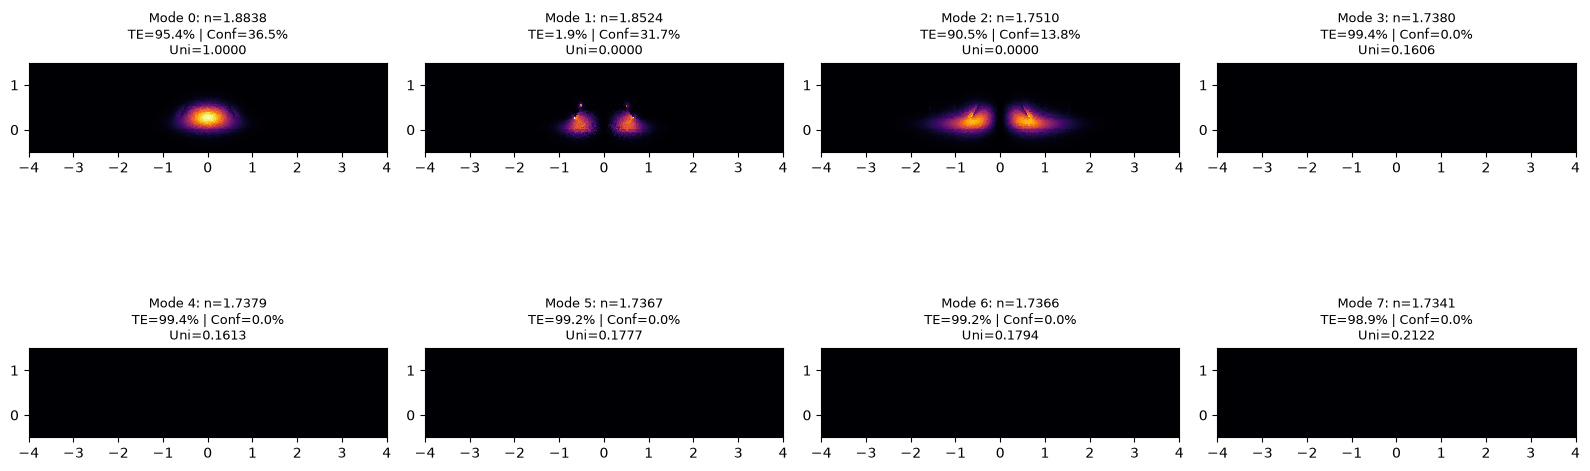

In [4]:
# %% [3] High-Precision Diagnostics & Mode Gallery
from skfem import Functional

core_ids = [s_id for name, s_id in name_to_id.items() if name.split("___")[0] == "core"]
is_core = np.zeros(skfem_mesh.nelements, dtype=float)
is_core[np.isin(tri_subdomains, core_ids)] = 1.0
is_core_field = basis_p0.interpolate(is_core)

@Functional(dtype=complex)
def _px(w):
    return np.abs(w["E"][0][0]) ** 2

@Functional(dtype=complex)
def _ptot(w):
    return (
        np.abs(w["E"][0][0]) ** 2
        + np.abs(w["E"][0][1]) ** 2
        + np.abs(w["E"][1]) ** 2
    )

@Functional(dtype=complex)
def _p_core(w):
    return w["is_core"] * (
        np.abs(w["E"][0][0]) ** 2
        + np.abs(w["E"][0][1]) ** 2
        + np.abs(w["E"][1]) ** 2
    )

@Functional(dtype=complex)
def _ex_core_signed(w):
    return w["is_core"] * np.real(w["E"][0][0])

@Functional(dtype=complex)
def _ex_core_abs(w):
    return w["is_core"] * np.abs(np.real(w["E"][0][0]))

mode_diagnostics = []

print("=" * 82)
print(f"{'Idx':<4} | {'Re(neff)':<10} | {'Im(neff)':<12} | {'TE %':<8} | {'Core Pwr %':<10} | {'Unipolarity':<12}")
print("-" * 82)

for idx, mode in enumerate(modes):
    E_interp = mode.basis.interpolate(mode.E)

    P_x = np.real(_px.assemble(mode.basis, E=E_interp))
    P_tot = np.real(_ptot.assemble(mode.basis, E=E_interp))
    P_core = np.real(_p_core.assemble(mode.basis, E=E_interp, is_core=is_core_field))

    te_ratio = P_x / P_tot
    core_confinement = P_core / P_tot

    signed = np.real(_ex_core_signed.assemble(mode.basis, E=E_interp, is_core=is_core_field))
    absval = np.real(_ex_core_abs.assemble(mode.basis, E=E_interp, is_core=is_core_field))

    unipolarity = 0.0000 if absval < 1e-12 else np.abs(signed) / absval

    neff_val = complex(mode.k / k0)

    mode_diagnostics.append({
        "index": idx,
        "mode": mode,
        "neff": neff_val,
        "te_ratio": te_ratio,
        "core_conf": core_confinement,
        "unipolarity": unipolarity,
    })

    print(
        f"{idx:<4} | "
        f"{neff_val.real:<10.5f} | "
        f"{neff_val.imag:<12.2e} | "
        f"{te_ratio * 100:<7.2f}% | "
        f"{core_confinement * 100:<9.2f}% | "
        f"{unipolarity:<12.4f}"
    )

print("=" * 82)

# Full Mode Gallery Plot
cols = 4
rows = int(np.ceil(len(modes) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(16, 3.4 * rows))
axes = np.array(axes).flatten()

for idx, diag in enumerate(mode_diagnostics):
    ax = axes[idx]
    E_interp = diag["mode"].basis.interpolate(diag["mode"].E)
    Ex_elem = np.mean(np.abs(E_interp[0].value[0]) ** 2, axis=-1)

    skfem_mesh.plot(Ex_elem, ax=ax, shading="flat", cmap="inferno")
    title_str = (
        f"Mode {idx}: n={diag['neff'].real:.4f}\n"
        f"TE={diag['te_ratio']*100:.1f}% | Conf={diag['core_conf']*100:.1f}%\n"
        f"Uni={diag['unipolarity']:.4f}"
    )
    ax.set_title(title_str, fontsize=9)
    ax.set_xlim([-4.0, 4.0])
    ax.set_ylim([-0.5, 1.5])
    ax.set_aspect("equal")

for j in range(len(modes), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [5]:
# %% [4] Overlap Integral, Vpi*L & Optical Attenuation
from skfem import Functional

# Fundamental TE mode identification
guided_cands = [
    d for d in mode_diagnostics
    if d["te_ratio"] >= 0.75 and d["core_conf"] >= 0.20 and d["unipolarity"] >= 0.85
]

if not guided_cands:
    raise RuntimeError("Fundamental TE rib mode not found. Check n_guess or eigensolver outputs.")

guided_cands.sort(key=lambda x: x["neff"].real, reverse=True)
fund_diag = guided_cands[0]
chosen_idx = fund_diag["index"]
fund_mode = fund_diag["mode"]
n_eff = fund_diag["neff"]

# 1. Optical Attenuation (Ohmic Metal Loss matching COMSOL Att_Opt)
att_opt_dB_m = np.abs(20.0 * np.log10(np.e) * k0_m * np.imag(n_eff))
att_opt_dB_cm = att_opt_dB_m / 100.0

# 2. Electro-Optic Overlap Integral (Gamma)
ln_mask = (mat_of_el == "LN")
Ex_dc_ln = np.zeros(skfem_mesh.nelements, dtype=float)
Ex_dc_ln[ln_mask] = Ex_dc[ln_mask]
Ex_dc_ln_field = basis_p0.interpolate(Ex_dc_ln)

E_fund_interp = fund_mode.basis.interpolate(fund_mode.E)

@Functional(dtype=complex)
def _num(w): 
    return w["Ex_dc_ln"] * np.abs(w["E"][0][0]) ** 2

@Functional(dtype=complex)
def _den(w): 
    return np.abs(w["E"][0][0]) ** 2

num = np.real(_num.assemble(fund_mode.basis, E=E_fund_interp, Ex_dc_ln=Ex_dc_ln_field))
den = np.real(_den.assemble(fund_mode.basis, E=E_fund_interp))

# Replace GAP with GAP_BOT
overlap = (GAP_BOT / V_bias) * (num / den)
Vpi_L_m = (GAP_BOT * 1e-6 * wl_m) / (r33 * np.abs(overlap) * (ne**3) * 2.0)
Vpi_L_Vcm = Vpi_L_m * 100.0
Vpi = Vpi_L_Vcm / L_cm

# 3. Formatted Simulation Summary
print("=" * 55)
print("             ELECTRO-OPTIC SIMULATION RESULTS")
print("=" * 55)
print(f"Selected Mode Index:         {chosen_idx}")
print(f"Effective Index (neff):      {n_eff.real:.6f} + {n_eff.imag:.2e}j")
print(f"Optical Attenuation:         {att_opt_dB_cm:.4e} dB/cm  ({att_opt_dB_m:.4e} dB/m)")
print(f"Overlap Integral (Gamma):    {overlap:.4f}")
print(f"|Vpi * L|:                   {Vpi_L_Vcm:.4f} V*cm")
print(f"|Vpi| (for L = {L_cm} cm):        {Vpi:.4f} V")
print("=" * 55)





# DIAGNOSTIC: 
# ---- loss localization + eigenvalue self-consistency -------------------
from skfem import Functional

im_eps = np.zeros(skfem_mesh.nelements)
for _m in ("Au_sig", "Au_gnd"):
    im_eps[mat_of_el == _m] = abs(MATERIALS[_m]["eps_opt"][0].imag)

@Functional(dtype=complex)
def _loss(w):
    return w["ie"] * (np.abs(w["E"][0][0])**2 + np.abs(w["E"][0][1])**2 + np.abs(w["E"][1])**2)

E_f = fund_mode.basis.interpolate(fund_mode.E)

def _loss_in(mask):
    fld = np.zeros(skfem_mesh.nelements); fld[mask] = im_eps[mask]
    return np.real(_loss.assemble(fund_mode.basis, E=E_f, ie=basis_p0.interpolate(fld)))

tot = _loss_in(im_eps > 0)
print(f"\nBUFFER_H = {BUFFER_H*1e3:.0f} nm")
print(f"  ratio R = integral / |Im(neff)| = {tot/abs(n_eff.imag):.6e}   <-- MUST be t-independent")
print("  loss dissipated per gold region:")
for _name, _sid in sorted(name_to_id.items()):
    _b = _name.split("___")[0]
    if _b not in polygons or not _b.startswith(("elR", "elL")):
        continue
    _msk = (tri_subdomains == _sid)
    if _msk.any():
        print(f"     {_b:<18} {100*_loss_in(_msk)/tot:6.2f} %")

             ELECTRO-OPTIC SIMULATION RESULTS
Selected Mode Index:         0
Effective Index (neff):      1.883805 + -1.39e-07j
Optical Attenuation:         4.8053e-02 dB/cm  (4.8053e+00 dB/m)
Overlap Integral (Gamma):    -0.3903
|Vpi * L|:                   2.1484 V*cm
|Vpi| (for L = 1.0 cm):        2.1484 V



BUFFER_H = 200 nm
  ratio R = integral / |Im(neff)| = 7.543022e+08   <-- MUST be t-independent
  loss dissipated per gold region:
     elL_bulk             0.07 %
     elL_skin0           33.69 %
     elL_skin0_cLI       16.26 %
     elL_skin1            0.00 %
     elL_skin1_cLO        0.00 %


     elR_bulk             0.07 %
     elR_skin0           33.65 %
     elR_skin0_cRI       16.25 %
     elR_skin1            0.00 %
     elR_skin1_cRO        0.00 %


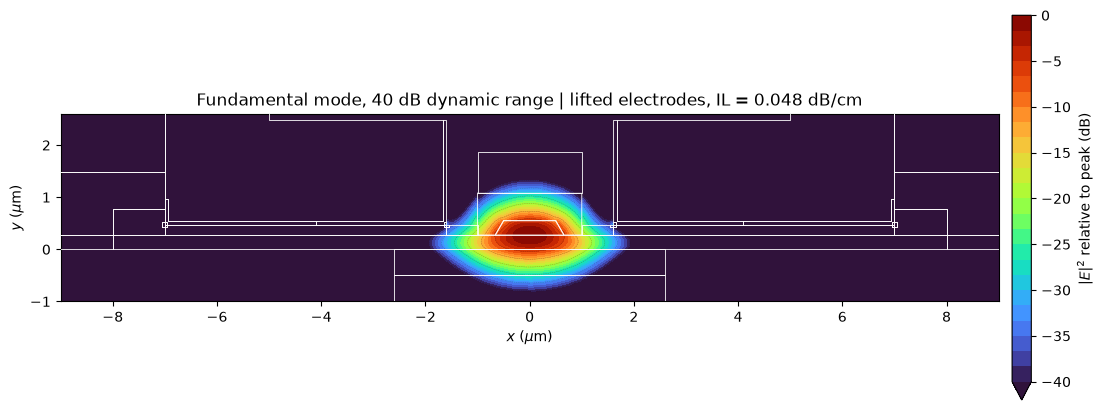

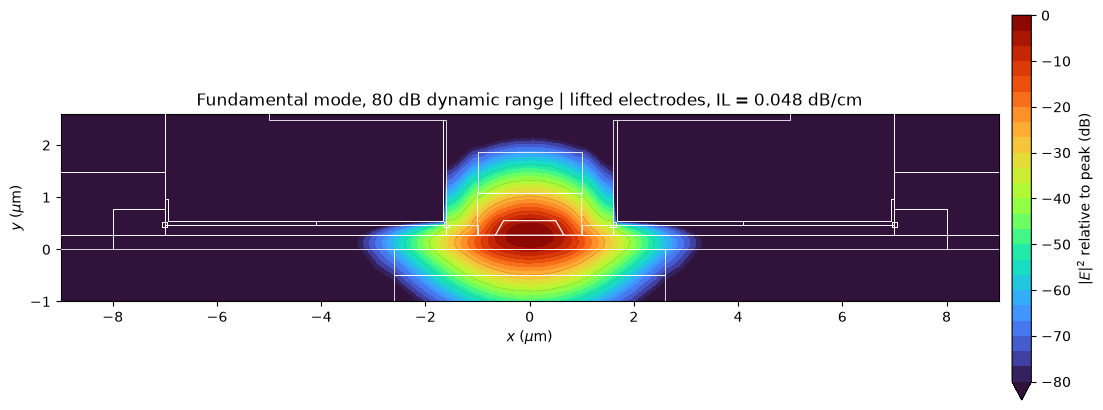

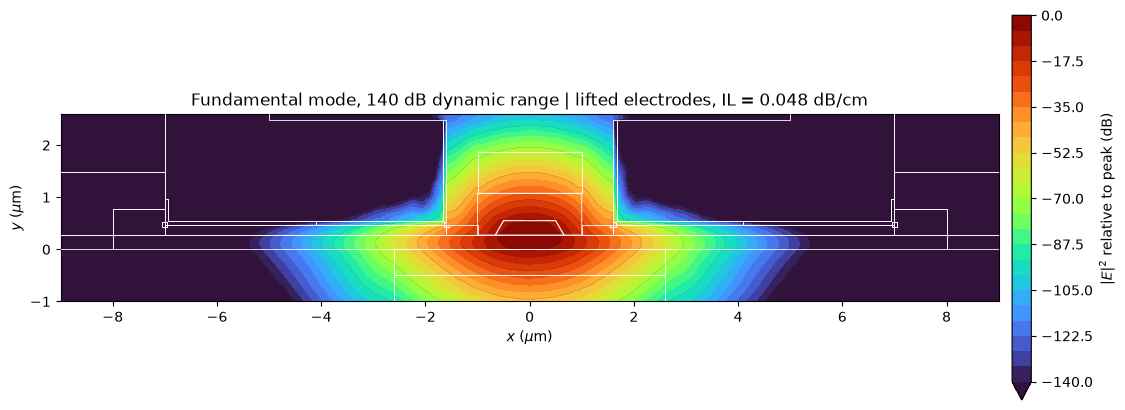

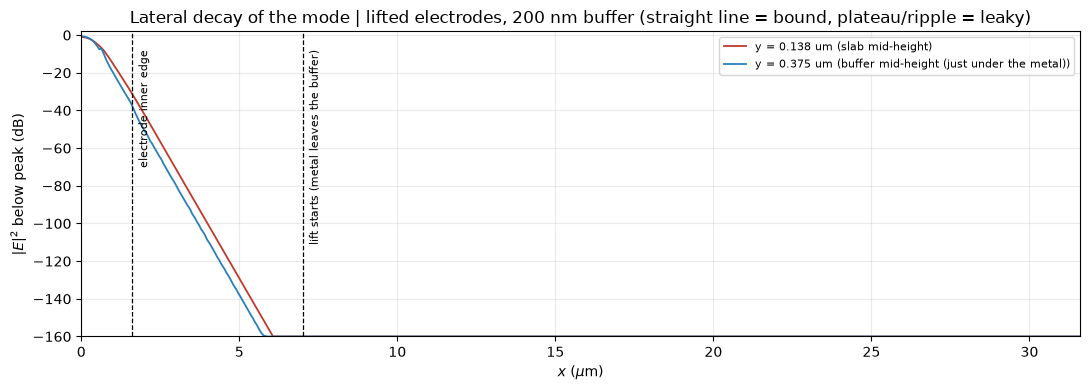

under the metal (1.9-6.0 um, then below the -160 dB floor):
   decay slope          : -28.98 dB/um
   ripple (peak-peak)   : 0.2 dB
   verdict              : BOUND -- evanescent decay under the metal


In [6]:
# %% [5] Optical mode: dB contour map + lateral tail cut
# Place this as a NEW cell AFTER cell [4] (it needs `fund_mode`, `polygons`, `DEV_W`).
import matplotlib.tri as mtri


def _val(f):
    """DiscreteField -> ndarray, tolerant of skfem version differences."""
    return np.asarray(f.value if hasattr(f, "value") else f)


# ---- total intensity |E|^2 per element, then averaged onto nodes -----------
_Ei = fund_mode.basis.interpolate(fund_mode.E)
_Et, _Ez = _val(_Ei[0]), _val(_Ei[1])
I_el = (np.mean(np.abs(_Et[0]) ** 2, axis=-1)
        + np.mean(np.abs(_Et[1]) ** 2, axis=-1)
        + np.mean(np.abs(_Ez) ** 2, axis=-1))

I_nodal = np.zeros(skfem_mesh.p.shape[1])
_cnt = np.zeros(skfem_mesh.p.shape[1])
for _i in range(skfem_mesh.t.shape[0]):
    np.add.at(I_nodal, skfem_mesh.t[_i], I_el)
    np.add.at(_cnt, skfem_mesh.t[_i], 1.0)
I_nodal /= np.maximum(_cnt, 1.0)

I_dB = 10.0 * np.log10(np.maximum(I_nodal / I_nodal.max(), 1e-16))
_tri = mtri.Triangulation(skfem_mesh.p[0], skfem_mesh.p[1], skfem_mesh.t.T)
_interp = mtri.LinearTriInterpolator(_tri, I_dB)


def _outline(ax, lw=0.7, color="white", alpha=0.85):
    """Draw material boundaries so the contours can be read against geometry."""
    for _nm, _pg in polygons.items():
        if _nm.startswith(("clad", "box_far", "slab_far", "buf_far")):
            continue
        for _part in (_pg.geoms if _pg.geom_type == "MultiPolygon" else [_pg]):
            _xy = np.asarray(_part.exterior.coords)
            ax.plot(_xy[:, 0], _xy[:, 1], lw=lw, color=color, alpha=alpha, zorder=5)


def plot_mode_db(dyn_db=60.0, xlim=(-9.0, 9.0), ylim=(-1.0, 2.6),
                 n_levels=24, cmap="turbo"):
    """Contour the mode in dB below peak. Raise dyn_db to see deeper into the tails."""
    fig, ax = plt.subplots(figsize=(12, 4.2))
    lv = np.linspace(-abs(dyn_db), 0.0, n_levels + 1)
    cf = ax.tricontourf(_tri, I_dB, levels=lv, cmap=cmap, extend="min")
    ax.tricontour(_tri, I_dB, levels=lv[::4], colors="k", linewidths=0.3, alpha=0.35)
    _outline(ax)
    cb = fig.colorbar(cf, ax=ax, pad=0.012)
    cb.set_label(r"$|E|^2$ relative to peak (dB)")
    ax.set_xlim(xlim); ax.set_ylim(ylim); ax.set_aspect("equal")
    ax.set_xlabel(r"$x$ ($\mu$m)"); ax.set_ylabel(r"$y$ ($\mu$m)")
    ax.set_title(rf"Fundamental mode, {dyn_db:.0f} dB dynamic range | "
                 rf"lifted electrodes, IL = {att_opt_dB_cm:.3f} dB/cm")
    plt.tight_layout(); plt.show()


# Interactive slider if ipywidgets is available; otherwise three fixed ranges.
try:
    from ipywidgets import interact, FloatSlider, fixed
    interact(plot_mode_db,
             dyn_db=FloatSlider(value=60, min=20, max=160, step=5,
                                description="dyn range (dB)", continuous_update=False),
             xlim=fixed((-9.0, 9.0)), ylim=fixed((-1.0, 2.6)),
             n_levels=fixed(24), cmap=fixed("turbo"))
except ImportError:
    # no ipywidgets: show three fixed ranges instead. Call plot_mode_db(dyn_db=...)
    # yourself, or widen xlim to (-25, 25) to see the full electrode span.
    for _d in (40, 80, 140):
        plot_mode_db(dyn_db=_d)


# ---- THE DIAGNOSTIC: lateral cut through the slab -------------------------
# A BOUND mode decays as a straight line in dB.
# A LEAKY mode decays, then flattens into a plateau / standing-wave ripple that
# runs all the way out under the electrodes.
fig, ax = plt.subplots(figsize=(11, 4.0))
x_max = GAP_BOT / 2.0 + EL_W          # out to the far edge of the electrode
_cuts = [(SLAB_H * 0.5, "slab mid-height", "#c0392b")]
if BUFFER_H > 1e-9:
    _cuts.append((SLAB_H + 0.5 * BUFFER_H, "buffer mid-height (just under the metal)", "#2980b9"))
else:
    _cuts.append((SLAB_H * 0.9, "slab top (just under the metal)", "#2980b9"))
for _y, _lab, _c in _cuts:
    _xs = np.linspace(0.0, x_max, 2000)
    _v = _interp(_xs, np.full_like(_xs, _y))
    ax.plot(_xs, _v, lw=1.3, color=_c, label=f"y = {_y:.3f} um ({_lab})")

ax.axvline(GAP_BOT / 2.0, color="k", ls="--", lw=0.9)
ax.text(GAP_BOT / 2.0 + 0.2, -8, "electrode inner edge", fontsize=8, rotation=90, va="top")
ax.axvline(GAP_BOT / 2.0 + LOW_W, color="k", ls="--", lw=0.9)
ax.text(GAP_BOT / 2.0 + LOW_W + 0.2, -8, "lift starts (metal leaves the buffer)",
        fontsize=8, rotation=90, va="top")
ax.set_xlabel(r"$x$ ($\mu$m)"); ax.set_ylabel(r"$|E|^2$ below peak (dB)")
ax.set_ylim(-160, 2); ax.set_xlim(0, x_max)
ax.grid(alpha=0.25)
ax.legend(fontsize=8, loc="upper right")
ax.set_title(rf"Lateral decay of the mode | lifted electrodes, {BUFFER_H*1e3:.0f} nm buffer "
             rf"(straight line = bound, plateau/ripple = leaky)")
plt.tight_layout(); plt.show()

# Quantify it UNDER THE METAL (between the inner edge and the lift): a bound mode
# keeps falling in a straight line there; a leaky one sits on a flat, rippled plateau.
_x0, _x1 = GAP_BOT / 2.0 + 0.3, GAP_BOT / 2.0 + LOW_W - 0.3
_xs = np.linspace(_x0, _x1, 400)
_v = np.asarray(_interp(_xs, np.full_like(_xs, SLAB_H * 0.5)))
_ok = np.isfinite(_v) & (_v > -159.0)          # I_dB is clipped at 1e-16 (-160 dB)
if _ok.sum() < 20:
    print(f"under the metal ({_x0:.1f}-{_x1:.1f} um): field below the -160 dB floor -> BOUND")
else:
    _fit = np.polyfit(_xs[_ok], _v[_ok], 1)
    _ripple = np.ptp(_v[_ok] - np.polyval(_fit, _xs[_ok]))
    _where = (f"{_xs[_ok].min():.1f}-{_xs[_ok].max():.1f} um"
              + ("" if _ok.all() else ", then below the -160 dB floor"))
    print(f"under the metal ({_where}):")
    print(f"   decay slope          : {_fit[0]:+.2f} dB/um")
    print(f"   ripple (peak-peak)   : {_ripple:.1f} dB")
    print("   verdict              : " + ("LEAKY -- flat plateau / standing wave under the metal"
                                        if _fit[0] > -3.0 else "BOUND -- evanescent decay under the metal"))